In [1]:
print("python")

python


In [ ]:
!pip install langgraph

In [3]:
!pip show ipython

Name: ipython
Version: 9.10.0
Summary: IPython: Productive Interactive Computing
Home-page: 
Author: The IPython Development Team
Author-email: ipython-dev@python.org
License: 
Location: C:\Users\pcell\AppData\Roaming\Python\Python311\site-packages
Requires: colorama, decorator, ipython-pygments-lexers, jedi, matplotlib-inline, prompt_toolkit, pygments, stack_data, traitlets, typing_extensions
Required-by: ipykernel, ipywidgets, jupyter-console


In [45]:
from langgraph.graph import StateGraph,END,START
from typing import Dict,TypedDict,List
from IPython.display import Image,display

In [4]:
class AgentClass(TypedDict):
    name:str
    age:str
    result:str

def userInfo(state:AgentClass)->AgentClass:
    state['result']="Hii I'am :"+state['name']+" My Age is :"+ state['age']
    return state

graph=StateGraph(AgentClass)
graph.add_node('userinfo',userInfo)
graph.set_entry_point('userinfo')
graph.set_finish_point('userinfo')
app=graph.compile()
result=app.invoke({'name':'kiran punna ','age':'20'})
print(result['result'])

Hii I'am :kiran punna  My Age is :20


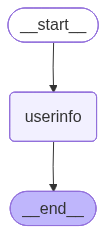

In [5]:
display(Image(app.get_graph().draw_mermaid_png()))

Multiple Inputs


In [35]:
class AgentClass(TypedDict):
    name:str
    age:int
    values:List[int]
    final=str

def multipleInputNode(state:AgentClass)->AgentClass:
    valmul=list(map(lambda x:x*x,state['values']))
    state["final"]="hi "+state['name']+', your age is '+str(state['age'])+', your multi '+str(valmul)
    print(state)
    return state

graph=StateGraph(AgentClass)
graph.add_node('multiinput',multipleInputNode)
graph.set_entry_point('multiinput')
graph.set_finish_point('multiinput')
app=graph.compile()
result=app.invoke({'name':'kiran punna','age':20,'values':[10,20,30,40]})

{'name': 'kiran punna', 'age': 20, 'values': [10, 20, 30, 40], 'final': 'hi kiran punna, your age is 20, your multi [100, 400, 900, 1600]'}


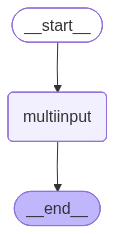

In [9]:
display(Image(app.get_graph().draw_mermaid_png()))

Sequential Nodes

In [39]:
class AgentClass(TypedDict):
    name:str
    age:int
    res:str

def firstNode(state:AgentClass)->AgentClass:
    state['res']=f"{state['name']}"
    return state

def secondNode(state:AgentClass)->AgentClass:
    state['res']=state['res']+f" your Age is : {state['age']}"
    return state

graph=StateGraph(AgentClass)
graph.add_node('first',firstNode)
graph.add_node('second',secondNode)
graph.set_entry_point('first')
graph.add_edge('first','second')
graph.set_finish_point('second')
app=graph.compile()
result=app.invoke({'name':'kiran','age':30})
print(result['res'])

kiran your Age is : 30


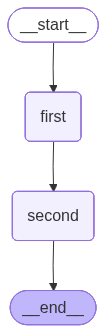

In [40]:
display(Image(app.get_graph().draw_mermaid_png()))

Conditional

In [ ]:
class AgentClass(TypedDict):
    num1:int
    num2:int
    operator:str
    functional_result:str

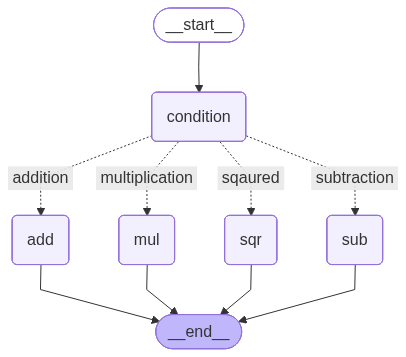

In [46]:
def Node1(state:AgentClass)->AgentClass:
    state['functional_result']=state['num1']+state['num2']
    return state

def Node2(state:AgentClass)->AgentClass:
    state['functional_result']=state['num1']-state['num2']
    return state

def Node3(state:AgentClass)->AgentClass:
    state['functional_result']=state['num1']*state['num2']
    return state

def Node4(state:AgentClass)->AgentClass:
    state['functional_result']=state['num1']**state['num2']
    return state

def conditionNode(state:AgentClass)->AgentClass:
    if state['operator']=='+':
        return "addition"
    if state['operator']=='-':
        return "subtraction"
    if state['operator']=='*':
        return "multiplication"
    if state['operator']=='**':
        return "sqaured"
graph=StateGraph(AgentClass)

graph.add_node('add',Node1)
graph.add_node('sub',Node2)
graph.add_node('mul',Node3)
graph.add_node('sqr',Node4)
graph.add_node('condition',lambda state:state)
graph.add_edge(START,'condition')
graph.add_conditional_edges(
    'condition',
    conditionNode,
    {'addition':'add',
     'subtraction':'sub',
     'multiplication':'mul',
     'sqaured':'sqr'
     }  
)
graph.add_edge('add',END)
graph.add_edge('sub',END)
graph.add_edge('mul',END)
graph.add_edge('sqr',END)
app=graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [50]:
result=app.invoke({"num1":20,'num2':30,'operator':'-'})
print(result)

{'num1': 20, 'num2': 30, 'operator': '-', 'functional_result': -10}
